In [9]:
# Instalação opcional: execute se algum pacote não estiver disponível
# %pip install pandas numpy matplotlib seaborn scipy openpyxl

from pathlib import Path
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

# Altere somente estes caminhos para os arquivos baixados localmente
CAMINHO_IRA_TRIAGE = Path(
    r'./Atendimentos_de_emergencia/ED_triage.csv'
)
CAMINHO_IRA_ADMISSION = Path(
    r'./Atendimentos_de_emergencia/ED_admission.csv'
)
CAMINHO_SIRI = Path(
    r'./Insuficiencia_cardiaca/VLOOKUP SHEET - Dataverse.xlsx'
)
PASTA_SAIDA = Path('./resultados_preprocessamento')
PASTA_SAIDA.mkdir(exist_ok=True)



In [10]:
# Carregamento dos arquivos locais — não há download automático
for caminho in [CAMINHO_IRA_TRIAGE, CAMINHO_IRA_ADMISSION, CAMINHO_SIRI]:
    if not caminho.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {caminho.resolve()}')

ira_triage = pd.read_csv(CAMINHO_IRA_TRIAGE, low_memory=False)
ira_admission = pd.read_csv(CAMINHO_IRA_ADMISSION, low_memory=False)

if CAMINHO_SIRI.suffix.lower() in ['.xlsx', '.xls']:
    # Use a primeira planilha consolidada do arquivo VLOOKUP
    siri = pd.read_excel(
        CAMINHO_SIRI,
        sheet_name='Combined Sheet VLookUp',
        na_values=['#N/A', '#DIV/0!', '#DIV/0']
    )
    siri_meta = None
elif CAMINHO_SIRI.suffix.lower() == '.sav':
    import pyreadstat
    siri, siri_meta = pyreadstat.read_sav(CAMINHO_SIRI, apply_value_formats=False)
else:
    raise ValueError('Use um arquivo .xlsx/.xls VLOOKUP ou .sav do Harvard Dataverse.')

print('IRA triage:', ira_triage.shape)
print('IRA admission:', ira_admission.shape)
print('SIRI/HF:', siri.shape)
display(ira_triage.head(3))
display(ira_admission.head(3))
display(siri.head(3))


IRA triage: (143582, 28)
IRA admission: (143280, 26)
SIRI/HF: (11744, 24)


,triage_code,gender,age,admission_year,admission_month,admission_day,admission_weekday,admission_hour,kindref,ChiefComplaint,explainer_id,NeedFastExecute,CriticalStatus,StuporStatus,PainGrade,MentalDistress,MaterialDistress,Source,BlooddpressurSystol,BlooddpressurDiastol,PulseRate,RespiratoryRate,Temperature,O2Saturation,AVPU,TriageGrade,operational_patient,ref_specialist
0,13960101008,Female,77,2017,3,21,2,2,5,Z03.89,1.0,2,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,0,0
1,13960101009,Male,42,2017,3,21,2,2,6,T07,2.0,2,0.0,0.0,0.0,2.0,0.0,2.0,NaN,NaN,86.0,18.0,NaN,96.0,A,3,0,0
2,13960101010,Female,71,2017,3,21,2,2,6,R10.84,3.0,2,1.0,2.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,0


,triage_code,PatientCode,DischargeFromED,Foreigners,gender,age,marital_Status,ResidentDate_year,ResidentDate_month,ResidentDate_day,ResidentDate_weekday,ResidentDate_hour,DischargeDate_year,DischargeDate_month,DischargeDate_day,DischargeDate_weekday,DischargeDate_hour,StatusOnDischarge,KindRef,IsGlobal,AccompainerRelation_id,ResidentDay,service_count_action,service_count_instrument,service_count_lab,service_count_graphy
0,13960101008,9600008,0,No,Female,75.0,2.0,2017,3,21,2,2,2017,3,31,5,0,3,5,0.0,2.0,10.0,0,0,0,0
1,13960101009,9600009,0,No,Male,41.0,2.0,2017,3,21,2,2,2017,3,23,4,0,2,6,0.0,3.0,2.0,0,0,0,0
2,13960101010,9600010,0,No,Female,71.0,2.0,2017,3,21,2,2,2017,3,21,2,0,2,6,0.0,2.0,0.0,0,0,0,0


,SEQN,MCQ010,AGQ030,MCQ053,MCQ160A,MCQ160B,MCQ160C,MCQ160D,MCQ160E,MCQ160F,MCQ160M,MCQ160P,MCQ160L,MCQ550,MCQ220,BPQ020,BPQ080,DIQ010,KIQ022,LBDLYMNO,LBDMONO,LBDNENO,SIRI,BMXBMI
0,130378,2.0,2.0,2,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2,2.0,1.9,0.3,2.2,0.347368,27.0
1,130379,2.0,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,2,2.0,1.6,0.9,3.6,2.025000,33.5
2,130380,2.0,2.0,2,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1,2.0,1.7,0.3,3.3,0.582353,29.7


In [11]:
# Funções gerais de diagnóstico
def missing_report(df):
    out = pd.DataFrame({
        'tipo': df.dtypes.astype(str),
        'ausentes_n': df.isna().sum(),
        'ausentes_pct': (df.isna().mean() * 100).round(2),
        'unicos': df.nunique(dropna=True),
    })
    return out.sort_values(['ausentes_pct', 'unicos'], ascending=[False, True])

def duplicate_report(df, nome):
    print(f'[{nome}] linhas={len(df):,}; duplicadas completas={df.duplicated().sum():,}; linhas únicas={df.drop_duplicates().shape[0]:,}')
    ids = [c for c in df.columns if c.upper() in {'SEQN','PATIENTCODE','PATIENT_CODE','TRIAGE_CODE','ID'} or c.lower().endswith('id')]
    for c in ids:
        print(f'  {c}: valores repetidos={(df[c].duplicated(keep=False) & df[c].notna()).sum():,}; únicos={df[c].nunique(dropna=True):,}')

def duplicate_columns(df):
    groups = {}
    for col in df.columns:
        key = tuple(df[col].astype('string').fillna('<NA>').tolist())
        groups.setdefault(key, []).append(col)
    return [cols for cols in groups.values() if len(cols) > 1]

def constant_columns(df):
    return [c for c in df.columns if df[c].nunique(dropna=False) <= 1]

def high_corr(df, threshold=0.90):
    num = df.select_dtypes(include=np.number)
    corr = num.corr().abs()
    pairs = []
    for i, c1 in enumerate(corr.columns):
        for c2 in corr.columns[i+1:]:
            value = corr.loc[c1, c2]
            if pd.notna(value) and value >= threshold:
                pairs.append((c1, c2, round(float(value), 4)))
    return pd.DataFrame(pairs, columns=['atributo_1','atributo_2','abs_correlacao']).sort_values('abs_correlacao', ascending=False)

def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    if tab.empty or min(tab.shape) < 2: return np.nan
    from scipy.stats import chi2_contingency
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.to_numpy().sum()
    phi2 = chi2 / n
    r, k = tab.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / max(1e-12, min(kcorr-1, rcorr-1)))

def categorical_redundancy(df, max_levels=30, threshold=.85):
    cols = [c for c in df.select_dtypes(exclude=np.number).columns if df[c].nunique(dropna=True) <= max_levels]
    rows=[]
    for i,c1 in enumerate(cols):
        for c2 in cols[i+1:]:
            z = df[[c1,c2]].dropna()
            if len(z) and z[c1].nunique()>1 and z[c2].nunique()>1:
                v=cramers_v(z[c1],z[c2])
                if pd.notna(v) and v>=threshold: rows.append((c1,c2,round(float(v),4)))
    return pd.DataFrame(rows, columns=['atributo_1','atributo_2','cramers_v']).sort_values('cramers_v', ascending=False)

def plot_missing(df, title, top=25):
    m = missing_report(df).head(top).sort_values('ausentes_pct')
    ax = m['ausentes_pct'].plot.barh(figsize=(10, max(4, top*.25)), color='#4472C4')
    ax.set_title(title); ax.set_xlabel('% de ausência'); ax.set_ylabel('')
    plt.tight_layout(); plt.show()

def find_col(df, candidates):
    norm = {re.sub(r'[^a-z0-9]','',c.lower()): c for c in df.columns}
    for candidate in candidates:
        key=re.sub(r'[^a-z0-9]','',candidate.lower())
        if key in norm: return norm[key]
    for c in df.columns:
        z=re.sub(r'[^a-z0-9]','',c.lower())
        if any(re.sub(r'[^a-z0-9]','',x.lower()) in z for x in candidates): return c
    return None


[SIRI/HF] linhas=11,744; duplicadas completas=0; linhas únicas=11,744
  SEQN: valores repetidos=0; únicos=11,744
Colunas constantes: []
Colunas exatamente duplicadas:


[]

,tipo,ausentes_n,ausentes_pct,unicos
SIRI,float64,4162,35.44,3080
MCQ160F,float64,3938,33.53,3
MCQ160M,float64,3938,33.53,4
MCQ160A,float64,3937,33.52,3
MCQ160C,float64,3937,33.52,3
MCQ160E,float64,3937,33.52,3
MCQ160P,float64,3937,33.52,3
MCQ160L,float64,3937,33.52,4
MCQ550,float64,3937,33.52,4
MCQ220,float64,3937,33.52,4


Pares numéricos com |r| >= 0.90


,atributo_1,atributo_2,abs_correlacao


Pares categóricos com Cramér V >= .85


,atributo_1,atributo_2,cramers_v


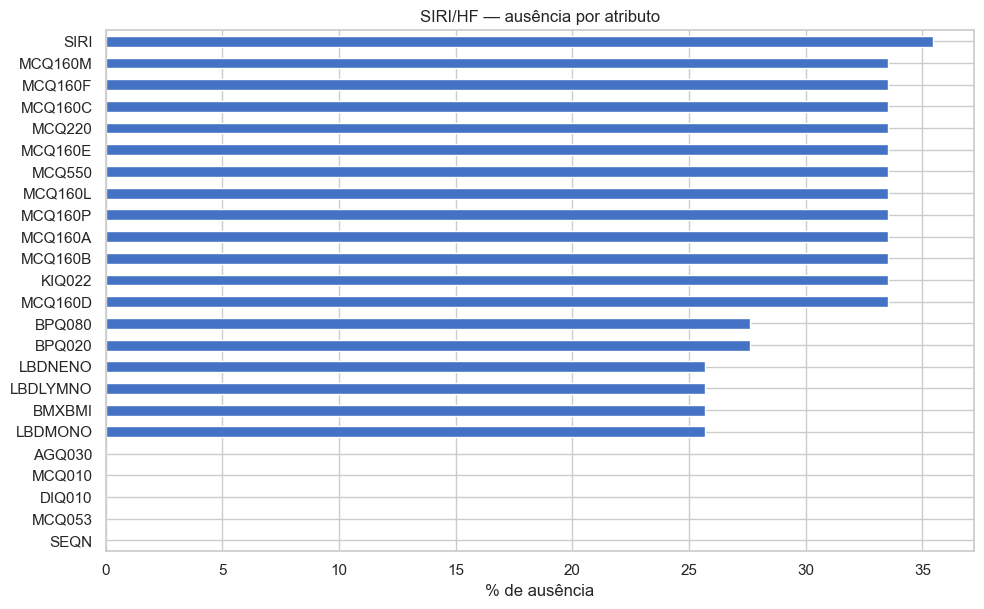

In [12]:
# Diagnóstico da base SIRI/HF
duplicate_report(siri, 'SIRI/HF')
print('Colunas constantes:', constant_columns(siri))
print('Colunas exatamente duplicadas:')
display(duplicate_columns(siri))
missing_siri = missing_report(siri)
display(missing_siri)
print('Pares numéricos com |r| >= 0.90')
display(high_corr(siri, .90))
print('Pares categóricos com Cramér V >= .85')
display(categorical_redundancy(siri))
plot_missing(siri, 'SIRI/HF — ausência por atributo')


Coluna insuficiência cardíaca: MCQ160B
Coluna grupo SIRI: None


,n
HF_label,
Não,7448
Ausente/ignorado,3953
Sim,343


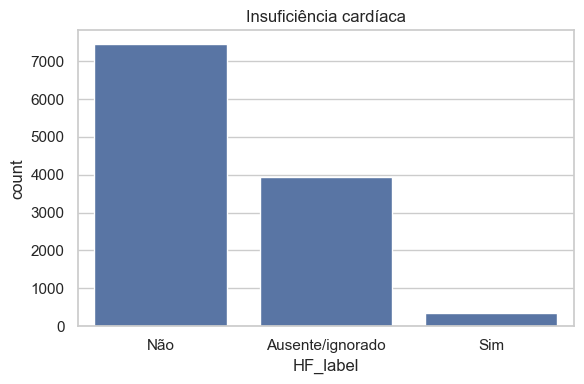

,atributo,n,% atributo=1 entre HF=1,% atributo=1 entre HF=2
0,BPQ020,7791,81.34,35.62
1,BPQ080,7791,67.06,37.76
4,MCQ160C,7790,48.10,3.13
2,DIQ010,7791,41.69,12.34
7,MCQ220,7790,32.65,14.14
6,MCQ160P,7790,32.07,6.07
5,MCQ160F,7789,20.70,3.93
8,MCQ053,7791,18.37,4.38
3,KIQ022,7791,15.74,3.54


In [13]:
# Preparação de variáveis-alvo para a base SIRI/HF
hf = find_col(siri, ['MCQ160B'])
siri_group = find_col(siri, ['SIRI_Group_Median'])
print('Coluna insuficiência cardíaca:', hf)
print('Coluna grupo SIRI:', siri_group)

# Mantém respostas válidas e cria rótulos interpretáveis
siri_view = siri.copy()
if hf:
    siri_view['HF_label'] = siri_view[hf].map({1:'Sim', 2:'Não'}).fillna('Ausente/ignorado')
if siri_group:
    siri_view['SIRI_group_label'] = siri_view[siri_group].map({0:'Baixo/mediana', 1:'Alto', 2:'Alto'}).fillna(siri_view[siri_group].astype('string'))

if 'HF_label' in siri_view:
    display(siri_view['HF_label'].value_counts(dropna=False).to_frame('n'))
    plt.figure(figsize=(6,4)); sns.countplot(data=siri_view, x='HF_label', order=siri_view['HF_label'].value_counts().index); plt.title('Insuficiência cardíaca'); plt.tight_layout(); plt.show()

if 'HF_label' in siri_view and 'SIRI_group_label' in siri_view:
    tab = pd.crosstab(siri_view['SIRI_group_label'], siri_view['HF_label'], normalize='index')*100
    display(tab.round(2))
    tab.plot(kind='bar', stacked=True, figsize=(8,4), colormap='Set2'); plt.ylabel('% dentro do grupo SIRI'); plt.title('Insuficiência cardíaca por grupo de SIRI'); plt.tight_layout(); plt.show()

# Associação exploratória entre atributos binários e insuficiência cardíaca
if hf:
    candidatos = ['BPQ020','BPQ080','DIQ010','KIQ022','MCQ160C','MCQ160F','MCQ160P','MCQ220','Obesity_BMXBMI','MCQ053']
    linhas=[]
    for c in candidatos:
        if c in siri_view.columns:
            z=siri_view[[c,hf]].dropna()
            z=z[z[hf].isin([1,2])]
            if len(z):
                linhas.append({'atributo':c,'n':len(z),'% atributo=1 entre HF=1':round(100*z.loc[z[hf]==1,c].eq(1).mean(),2),'% atributo=1 entre HF=2':round(100*z.loc[z[hf]==2,c].eq(1).mean(),2)})
    display(pd.DataFrame(linhas).sort_values('% atributo=1 entre HF=1', ascending=False))


[IRA_triage] linhas=143,582; duplicadas completas=174; linhas únicas=143,408
  triage_code: valores repetidos=442; únicos=143,346
  explainer_id: valores repetidos=34,245; únicos=14
Colunas constantes: []
Colunas exatamente duplicadas: []
Ausência:


,tipo,ausentes_n,ausentes_pct,unicos
Temperature,float64,143443,99.90,6
BlooddpressurSystol,float64,118921,82.82,91
BlooddpressurDiastol,float64,118622,82.62,72
RespiratoryRate,float64,110143,76.71,30
explainer_id,float64,109327,76.14,14
PulseRate,float64,108360,75.47,96
O2Saturation,float64,105923,73.77,20
AVPU,object,90558,63.07,4
Source,float64,87549,60.97,3
CriticalStatus,float64,10380,7.23,3


Pares numéricos com |r| >= 0.90


,atributo_1,atributo_2,abs_correlacao
0,triage_code,admission_year,0.9667


Pares categóricos com Cramér V >= .85


,atributo_1,atributo_2,cramers_v


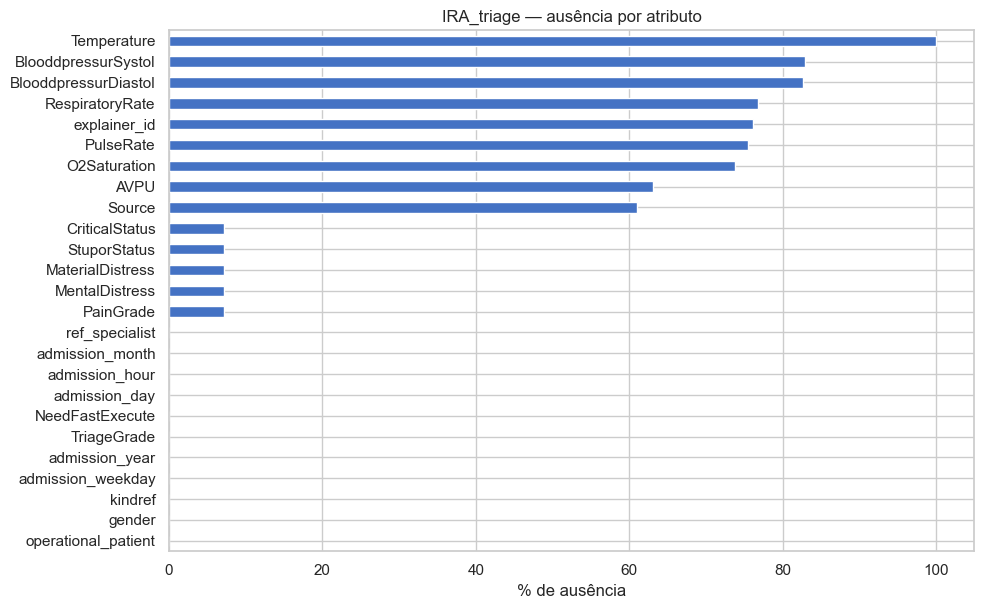

[IRA_admission] linhas=143,280; duplicadas completas=0; linhas únicas=143,280
  triage_code: valores repetidos=98; únicos=143,224
  PatientCode: valores repetidos=0; únicos=143,280
  AccompainerRelation_id: valores repetidos=142,490; únicos=10
Colunas constantes: ['DischargeDate_hour', 'service_count_action', 'service_count_instrument', 'service_count_lab', 'service_count_graphy']
Colunas exatamente duplicadas: [['DischargeDate_hour', 'service_count_action', 'service_count_instrument', 'service_count_lab', 'service_count_graphy']]
Ausência:


,tipo,ausentes_n,ausentes_pct,unicos
AccompainerRelation_id,float64,790,0.55,10
marital_Status,float64,19,0.01,6
DischargeDate_hour,int64,0,0.00,1
service_count_action,int64,0,0.00,1
service_count_instrument,int64,0,0.00,1
service_count_lab,int64,0,0.00,1
service_count_graphy,int64,0,0.00,1
DischargeFromED,int64,0,0.00,2
Foreigners,object,0,0.00,2
gender,object,1,0.00,2


Pares numéricos com |r| >= 0.90


,atributo_1,atributo_2,abs_correlacao
2,ResidentDate_year,DischargeDate_year,0.9977
0,triage_code,ResidentDate_year,0.9666
1,triage_code,DischargeDate_year,0.9655
3,ResidentDate_month,DischargeDate_month,0.9405


Pares categóricos com Cramér V >= .85


,atributo_1,atributo_2,cramers_v


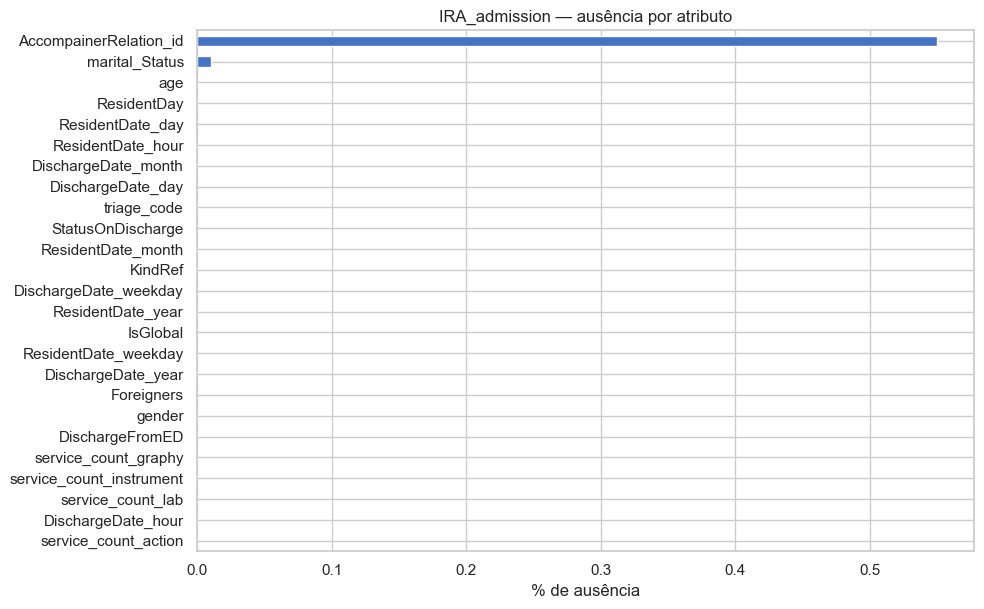

In [14]:
# Diagnóstico da base de emergência do Irã
for nome, df in [('IRA_triage', ira_triage), ('IRA_admission', ira_admission)]:
    duplicate_report(df, nome)
    print('Colunas constantes:', constant_columns(df))
    print('Colunas exatamente duplicadas:', duplicate_columns(df))
    print('Ausência:')
    display(missing_report(df))
    print('Pares numéricos com |r| >= 0.90')
    display(high_corr(df, .90))
    print('Pares categóricos com Cramér V >= .85')
    display(categorical_redundancy(df))
    plot_missing(df, f'{nome} — ausência por atributo')


{'triage': 'TriageGrade', 'critical': 'CriticalStatus', 'saturacao': 'O2Saturation', 'dor': 'PainGrade'}


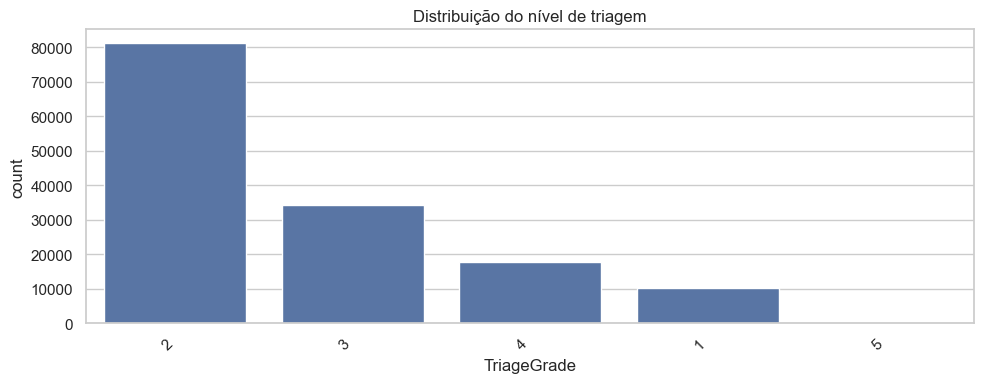

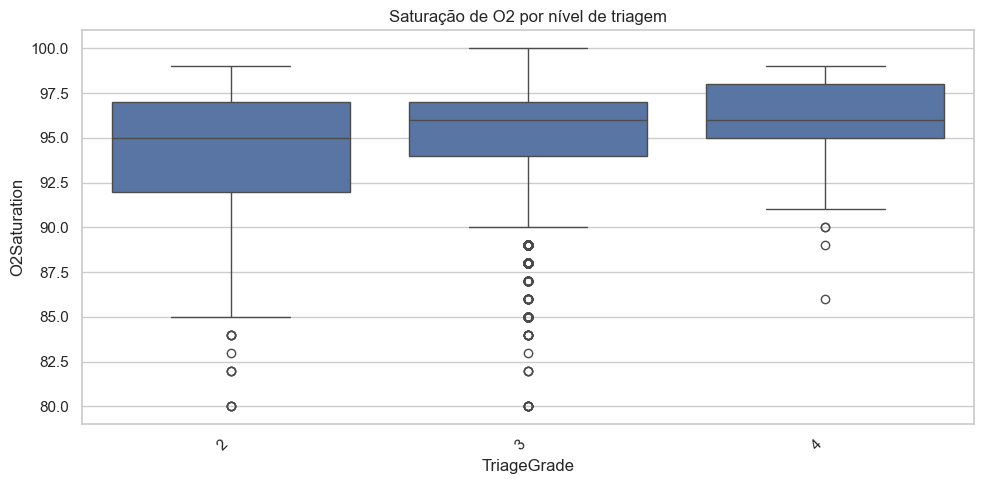

TriageGrade,1,2,3,4,5
PainGrade,,,,,
0.0,0.0,95.65,2.99,1.35,0.00
1.0,0.0,12.00,53.14,34.83,0.03
2.0,0.0,17.43,52.09,30.46,0.03
3.0,0.0,18.10,56.08,25.80,0.02
4.0,0.0,39.29,42.12,18.57,0.02
5.0,0.0,69.32,22.70,7.95,0.04
6.0,0.0,85.29,9.81,4.90,0.00
7.0,0.0,76.56,14.06,9.38,0.00
8.0,0.0,83.33,12.50,4.17,0.00


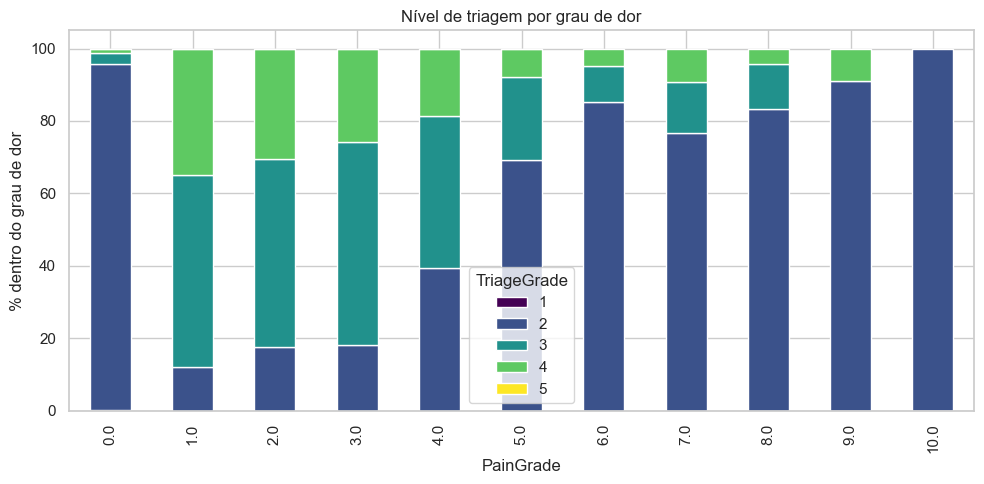

Coluna de desfecho da admissão: StatusOnDischarge


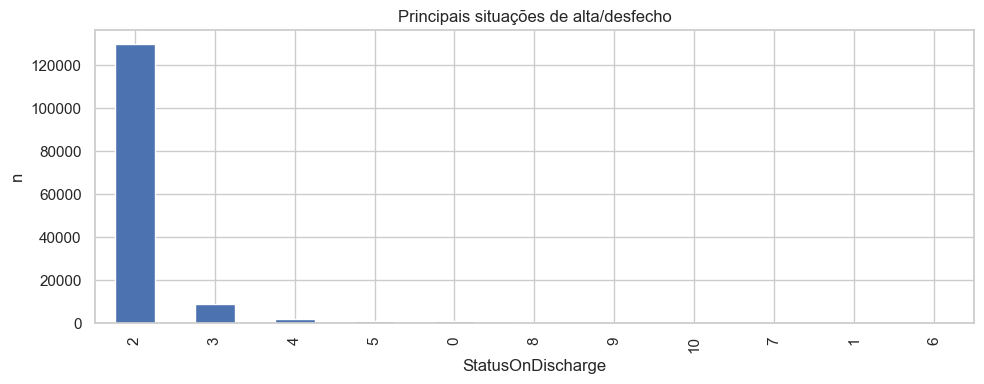

In [15]:
# Visualizações da base do Irã em relação a urgência e desfecho
triage_col = find_col(ira_triage, ['TriageGrade','triage_grade','Triage'])
critical_col = find_col(ira_triage, ['CriticalStatus','Critical'])
sat_col = find_col(ira_triage, ['O2Saturation','O2Sat','Saturation'])
pain_col = find_col(ira_triage, ['PainGrade','Pain'])
print({'triage':triage_col,'critical':critical_col,'saturacao':sat_col,'dor':pain_col})

if triage_col:
    plt.figure(figsize=(10,4)); order=ira_triage[triage_col].value_counts(dropna=False).index; sns.countplot(data=ira_triage, x=triage_col, order=order); plt.xticks(rotation=45, ha='right'); plt.title('Distribuição do nível de triagem'); plt.tight_layout(); plt.show()

if sat_col and triage_col:
    z=ira_triage[[sat_col,triage_col]].copy(); z[sat_col]=pd.to_numeric(z[sat_col], errors='coerce'); z=z.dropna()
    if len(z):
        plt.figure(figsize=(10,5)); sns.boxplot(data=z, x=triage_col, y=sat_col); plt.xticks(rotation=45, ha='right'); plt.title('Saturação de O2 por nível de triagem'); plt.tight_layout(); plt.show()

if pain_col and triage_col:
    tab=pd.crosstab(ira_triage[pain_col], ira_triage[triage_col], normalize='index')*100
    display(tab.round(2)); tab.plot(kind='bar', stacked=True, figsize=(10,5), colormap='viridis'); plt.ylabel('% dentro do grau de dor'); plt.title('Nível de triagem por grau de dor'); plt.tight_layout(); plt.show()

discharge_col = find_col(ira_admission, ['StatusOnDischarge','DischargeFromED','DischargeStatus'])
print('Coluna de desfecho da admissão:', discharge_col)
if discharge_col:
    plt.figure(figsize=(10,4)); ira_admission[discharge_col].value_counts(dropna=False).head(15).plot.bar(); plt.title('Principais situações de alta/desfecho'); plt.ylabel('n'); plt.tight_layout(); plt.show()


In [16]:
# Simulação de decisões de pré-processamento — não sobrescreve os dados originais
def aplicar_preprocessamento(df, max_missing=.40, corr_threshold=.90):
    out=df.copy()
    antes=len(out)
    out=out.drop_duplicates().copy()
    removidas_constantes=constant_columns(out)
    out=out.drop(columns=removidas_constantes, errors='ignore')
    miss=out.isna().mean()
    removidas_missing=miss[miss>max_missing].index.tolist()
    out=out.drop(columns=removidas_missing, errors='ignore')
    pares=high_corr(out, corr_threshold)
    # Não remove automaticamente correlacionadas; devolve pares para decisão do pesquisador.
    resumo={'linhas_antes':antes,'linhas_depois':len(out),'duplicatas_removidas':antes-len(df.drop_duplicates()),'constantes_removidas':removidas_constantes,'missing_removidas':removidas_missing,'pares_correlacionados':pares}
    return out,resumo

siri_teste, resumo_siri = aplicar_preprocessamento(siri, max_missing=.40, corr_threshold=.90)
ira_teste, resumo_ira = aplicar_preprocessamento(ira_triage, max_missing=.40, corr_threshold=.90)
print('SIRI/HF'); print({k:v for k,v in resumo_siri.items() if k!='pares_correlacionados'}); display(resumo_siri['pares_correlacionados'])
print('IRA triagem'); print({k:v for k,v in resumo_ira.items() if k!='pares_correlacionados'}); display(resumo_ira['pares_correlacionados'])

# Regra recomendada: não apagar automaticamente atributos correlacionados.
# Documente qual variável foi mantida e por quê, especialmente se uma for derivada de outra.


SIRI/HF
{'linhas_antes': 11744, 'linhas_depois': 11744, 'duplicatas_removidas': 0, 'constantes_removidas': [], 'missing_removidas': []}


,atributo_1,atributo_2,abs_correlacao


IRA triagem
{'linhas_antes': 143582, 'linhas_depois': 143408, 'duplicatas_removidas': 174, 'constantes_removidas': [], 'missing_removidas': ['explainer_id', 'Source', 'BlooddpressurSystol', 'BlooddpressurDiastol', 'PulseRate', 'RespiratoryRate', 'Temperature', 'O2Saturation', 'AVPU']}


,atributo_1,atributo_2,abs_correlacao
0,triage_code,admission_year,0.9667


In [17]:
# Exportar relatórios para CSV para anexar à documentação da IC
OUT = PASTA_SAIDA
OUT.mkdir(exist_ok=True)
missing_report(siri).to_csv(OUT/'siri_missing.csv')
high_corr(siri,.90).to_csv(OUT/'siri_correlacoes_altas.csv', index=False)
missing_report(ira_triage).to_csv(OUT/'ira_triage_missing.csv')
high_corr(ira_triage,.90).to_csv(OUT/'ira_triage_correlacoes_altas.csv', index=False)
missing_report(ira_admission).to_csv(OUT/'ira_admission_missing.csv')
high_corr(ira_admission,.90).to_csv(OUT/'ira_admission_correlacoes_altas.csv', index=False)
print('Relatórios gravados em:', OUT.resolve())


Relatórios gravados em: D:\Ciências da Computação\PUCMG\CienciasDaComputação\Iniciação Cientifica\Mark Alan\resultados_preprocessamento
